In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import io
import typing

import mne
import numpy
import pandas
import cairosvg
import PIL.Image
import matplotlib.pyplot as plt
import matplotlib.offsetbox as mob

import SDA.analytics

In [3]:
def SourceFilter(row):
    if row['Source'].startswith('dissim'):
        return 'dissim'
    return row['Source']

def MakeSourceRenamer(epochs: mne.Epochs):
    def SourceRenamer(initial: str) -> str:
        if initial == 'dissim':
            return 'Pearson dissim.'
        if initial == 'overall':
            return 'Overall proc.'
        ind = initial.find('-') + 1
        comp = int(initial[ind:])
        return f'Comp. {epochs.ch_names[comp]}'
    return SourceRenamer

def AlgorithmRenamer(row):
    return {
        'amplitude-betti-1':        'Betti amp., p=1',
        'amplitude-betti-2':        'Betti amp., p=2',

        'amplitude-bottleneck':     'Bottleneck amp.',
        'amplitude-wasserstein-1':  'Wasserstein amp., p=1',
        'amplitude-wasserstein-2':  'Wasserstein amp., p=2',
        
        'amplitude-landscape-1-1':  'Pers. land. amp., p=1',
        'amplitude-landscape-1-2':  'Pers. land. amp., p=1',
        'amplitude-landscape-2-1':  'Pers. land. amp., p=2',
        'amplitude-landscape-2-2':  'Pers. land. amp., p=2',
        
        'amplitude-silhouette-1-1': 'Pers. silh. amp., p=1',
        'amplitude-silhouette-1-2': 'Pers. silh. amp., p=1',
        'amplitude-silhouette-2-1': 'Pers. silh. amp., p=2',
        'amplitude-silhouette-2-2': 'Pers. silh. amp., p=2',

        'bd2':                      'Stats, (b + d) / 2',
        'life':                     'Stats, lifetimes',
        'betti':                    'Stats, Betti curves',
        'landscape':                'Stats, pers. landscape',
        'silhouette-1':             'Stats, lvl 1 pers. silh.',
        'silhouette-2':             'Stats, lvl 2 pers. silh.',
        
        'entropy':                  'Persistence entropy',
        'numberofpoints':           'Number of points',
    }[row]

def DimensionRenamer(row):
    return {
        'all':        'All',
        'dim-1':      'Dimension 1',
        'dim-2':      'Dimension 2',
        'dim-3':      'Dimension 3',
        'dim-4':      'Dimension 4',
        'dim-5':      'Dimension 5',
        'norm-1':     'Amp. norm, p=1',
        'norm-2':     'Amp. norm, p=2',
    }[row]

def StatRenamer(row):
    return {
        'kurtosis':      'Kurtosis',
        'skew':          'Skew',
        'max':           'Maximum',
        'mean':          'Mean',
        'median':        'Median',
        'norm-1':        'Norm with p=1',
        'norm-2':        'Norm with p=2',
        'percentile-25': 'Percentile - 25',
        'percentile-75': 'Percentile - 75',
        'std':           'Standard deviation',
        'sum':           'Sum',
    }[row]


In [4]:
def draw_eeg(src_folder, results_folder, ax, title: str, add_noise: bool = False):
    raw_data = mne.io.read_raw_fif(f"{src_folder}/data_rr_filt-raw.fif", verbose='error')# .drop_channels(ch_names = [ "A1", "A2" ])
    epochs = mne.read_epochs(f"{src_folder}/epochs_filt_rr-epo.fif", verbose='error')
    # raw_data = mne.io.read_raw_fif(f"{src_folder}/data.fif", verbose='error')
    # epochs = mne.read_epochs(f"{src_folder}/epochs.fif", verbose='error')
    
    best_edges = numpy.loadtxt(f"{results_folder}/best_edges.txt").astype(int)
    pca_features = numpy.load(f"{results_folder}/pca_features.npy")
    df_st_edges = pandas.read_csv(f"{results_folder}/df_st_edges.csv")
    best_result = pandas.read_csv(f"{results_folder}/best_result.csv").iloc[0]

    st_edges_list = [ ]
    for st_edges in df_st_edges["St_edges"]:
        st_edges = numpy.fromstring(st_edges.strip('[]'), sep = ' ', dtype = numpy.uint)
        st_edges_list.append(st_edges)
    df_st_edges["St_edges"] = st_edges_list

    ax.set_title(f"{title}. Average Silhouette: {round(best_result['Avg-Silh'], 2)}")
    SDA.analytics.plot_eeg_stages(raw_data, best_edges, epochs, pca_features, df_st_edges, best_result, ax = ax, resolution = 2, add_noise = add_noise)

def draw_features(iv_qsda: pandas.DataFrame, group_by: str, renamer: typing.Callable[[str], str], ax, title: str):
    stats = iv_qsda.groupby(by = group_by).mean(numeric_only = True).sort_values(by = 'score').reset_index()
    stats[group_by] = stats[group_by].apply(renamer)

    stats['score'] = stats['score'] / stats['score'].max()
    stats.plot.barh(x = group_by, y = 'score', ax = ax, color = (1, 0, 0, 0.66))
    
    stats['IV'] = stats['IV'] / stats['IV'].max()
    stats.plot.barh(x = group_by, y = 'IV', ax = ax, color = (0, 0.3, 1, 0.66))

    ax.set_title(title)
    ax.get_legend().remove()
    ax.xaxis.set_label_text('')
    ax.yaxis.set_label_text('')

def draw_sources_heatmap(epochs: mne.Epochs, iv_qsda: pandas.DataFrame, agg_by: str, fig, top: float, title: str, template: str):
    iv_qsda['channel_id'] = iv_qsda['Source'].apply(
        lambda source: source[len('channel-'):] if source.startswith('channel-') else None
    )
    iv_qsda = iv_qsda[~iv_qsda["channel_id"].isna()][["channel_id", "score", "IV"]]

    stats = {}
    for _, row in iv_qsda.groupby(by = 'channel_id').mean().reset_index().iterrows():
        channel_name = epochs.ch_names[int(row['channel_id'])]
        stats[channel_name] = row[agg_by]
    svg = SDA.analytics.draw_sources_heatmap(stats, template)
    png = cairosvg.svg2png(bytestring=svg, dpi = 7200, output_width = 720, output_height = 720)
    image = PIL.Image.open(io.BytesIO(png))
    
    text = mob.TextArea(title, textprops={"fontsize": 30})
    img = mob.OffsetImage(image)
    packed_content = mob.VPacker(children=[text, img], align="center", pad=0, sep=20)
    fig.add_artist(
        mob.AnnotationBbox(packed_content, (0.96, top), xycoords='figure fraction', box_alignment=(1, 1), frameon=False)
    )

def draw(subj, subj_name, exp, template: str):
    src = f"E:/CourseProject/{subj}/src"
    # src = f"E:/CourseProject/{subj}"
    traditional = f"E:/CourseProject/{subj}/{exp}/results/traditional"
    topological = f"E:/CourseProject/{subj}/{exp}/results/topological"
    best_topological = f"E:/CourseProject/{subj}/{exp}/results/best_topological"
    combined = f"E:/CourseProject/{subj}/{exp}/results/combined"
    noise = f"{subj}/exp_noise/results/best_topological"
    
    IV = f"E:/CourseProject/{subj}/{exp}/IV"
    qsda = f"E:/CourseProject/{subj}/{exp}/qsda"

    mosaic = [
        ['traditional',      'source',         '.'     ],
        ['traditional',      'source',         '.'     ],
        ['topological',      'source',         '.'     ],
        ['topological',      'source',         '.'     ],
        ['best_topological', 'source',         '.'     ],
        ['best_topological', 'source',         '.'     ],
        ['combined',         'dimension',      'method'],
        ['combined',         'dimension',      'method'],
        ['noise',            'characteristic', 'method'],
        ['noise',            'characteristic', 'method']
    ]
    fig, axes = plt.subplot_mosaic(mosaic, figsize=(70, 40), width_ratios = (4, 1, 1), layout = 'tight')
    fig.suptitle(f"Subject {subj_name}", fontsize = 36, fontweight = 'bold')
    
    draw_eeg(src, traditional, axes["traditional"], title = "Traditional features")
    draw_eeg(src, topological, axes["topological"], title = "Topological features")
    draw_eeg(src, best_topological, axes["best_topological"], title = "Topological features (QSDA)")
    draw_eeg(src, combined, axes["combined"], title = "Combined features")
    draw_eeg(src, noise, axes["noise"], title = "Topological features (gaussian noise)", add_noise = True)
    
    iv = pandas.read_csv(f"{IV}/IV.csv")
    qsda = pandas.read_csv(f"{qsda}/scores.csv")
    iv_qsda = qsda.join(iv, lsuffix = "name", rsuffix = "Feature")
    iv_qsda["score"] = iv_qsda["score"] * (iv_qsda["unique_values"] >= 200)
    iv_qsda[["Source", "Algorithm", "Dimension", "Stat"]] = iv_qsda['name'].str.split(' ', expand = True)
    iv_qsda["Source"] = iv_qsda.apply(SourceFilter, axis = 1)
    epochs = mne.read_epochs(f"{src}/epochs_filt_rr-epo.fif", verbose='error')
    if exp == "exp_full_flow":
        epochs = epochs.drop_channels(ch_names = [ "A1", "A2" ])

    draw_features(iv_qsda, 'Source', MakeSourceRenamer(epochs), axes['source'], 'Extraction techniques and brain regions')
    draw_features(iv_qsda, 'Algorithm', AlgorithmRenamer, axes['method'], 'Vectorization methods')
    draw_features(iv_qsda, 'Dimension', DimensionRenamer, axes['dimension'], 'Simplex dimensions')
    draw_features(iv_qsda, 'Stat', StatRenamer, axes['characteristic'], 'Statistical characteristics')

    draw_sources_heatmap(epochs, iv_qsda, 'score', fig, 0.96, 'QSDA scores', template)
    draw_sources_heatmap(epochs, iv_qsda, 'IV', fig, 0.67, 'IV scores', template)
    
    return fig

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams.update({'font.size': 28})

pp = PdfPages('sda_supplementary_full_flow.pdf')
pp.savefig(draw("Subj1", 1, "exp_full_flow", template = "subj_1_12"))
pp.savefig(draw("Subj2", 2, "exp_full_flow", template = "subj_1_12"))
pp.savefig(draw("Subj3", 3, "exp_full_flow", template = "subj_1_12"))
pp.close()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams.update({'font.size': 28})

pp = PdfPages('sda_supplementary_reduced_flow.pdf')
for i in range(1, 31, 1):
    if i >= 1 and i <= 12:
        template = 'subj_1_12'
    elif i >= 13 and i <= 26:
        template = 'subj_13_26'
    elif i >= 27 and i <= 30:
        template = 'subj_27_30'
    pp.savefig(draw(f"phase2/Subj{i}", i, "exp_reduced_flow", template = template))
pp.close()

In [5]:
def get_silh(src_folder, subj, exp, result):
    best_result = pandas.read_csv(f"{src_folder}/{subj}/{exp}/results/{result}/best_result.csv").iloc[0]
    return round(best_result['Avg-Silh'], 3)

def draw(subj, subj_name, exp):
    original_traditional = get_silh("E:/CourseProject", subj, exp, "traditional")
    original_topological = get_silh("E:/CourseProject", subj, exp, "topological")
    original_best_topological = get_silh("E:/CourseProject", subj, exp, "best_topological")
    original_combined = get_silh("E:/CourseProject", subj, exp, "combined")
    noise_best_topological = get_silh("./", subj, "exp_noise", "best_topological")
    shuffled_traditional = get_silh("E:/CourseProject", subj, "exp_shuffled", "traditional")
    shuffled_best_topological = get_silh("E:/CourseProject", subj, "exp_shuffled", "best_topological")
    shuffled_combined = get_silh("E:/CourseProject", subj, "exp_shuffled", "combined")
    return f'''
        Subject {subj_name} (original)       & {original_traditional} & {original_topological} & {original_best_topological} & {original_combined} \\\\
        Subject {subj_name} (gaussian noise) & -                      & -                      & {noise_best_topological}    & -                   \\\\
        Subject {subj_name} (shuffled)       & {shuffled_traditional} & -                      & {shuffled_best_topological} & {shuffled_combined} \\\\
    '''

In [ ]:
rows = "\\bs".join([ draw(f"Subj{i}", i, "exp_full_flow") for i in range(1, 4) ])
table = f'''
\\Table{{
    Silhouette coefficients of results obtained from original, noisy, and shuffled recordings of all subject using different sets of features
}}
    \\br
    EEG recording & Traditional & Topological & Best topological (QSDA) & Combined\\
    \\mr {rows} \\br
\\endTable'''

print(table)

In [ ]:
rows = "\\bs".join([ draw(f"phase2/Subj{i}", i, "exp_reduced_flow") for i in range(1, 31) ])
table = f'''
\\Table{{
    Silhouette coefficients of results obtained from original, noisy, and shuffled recordings of all subject using different sets of features
}}
    \\br
    EEG recording & Traditional & Topological & Best topological (QSDA) & Combined\\
    \\mr {rows} \\br
\\endTable'''

print(table)

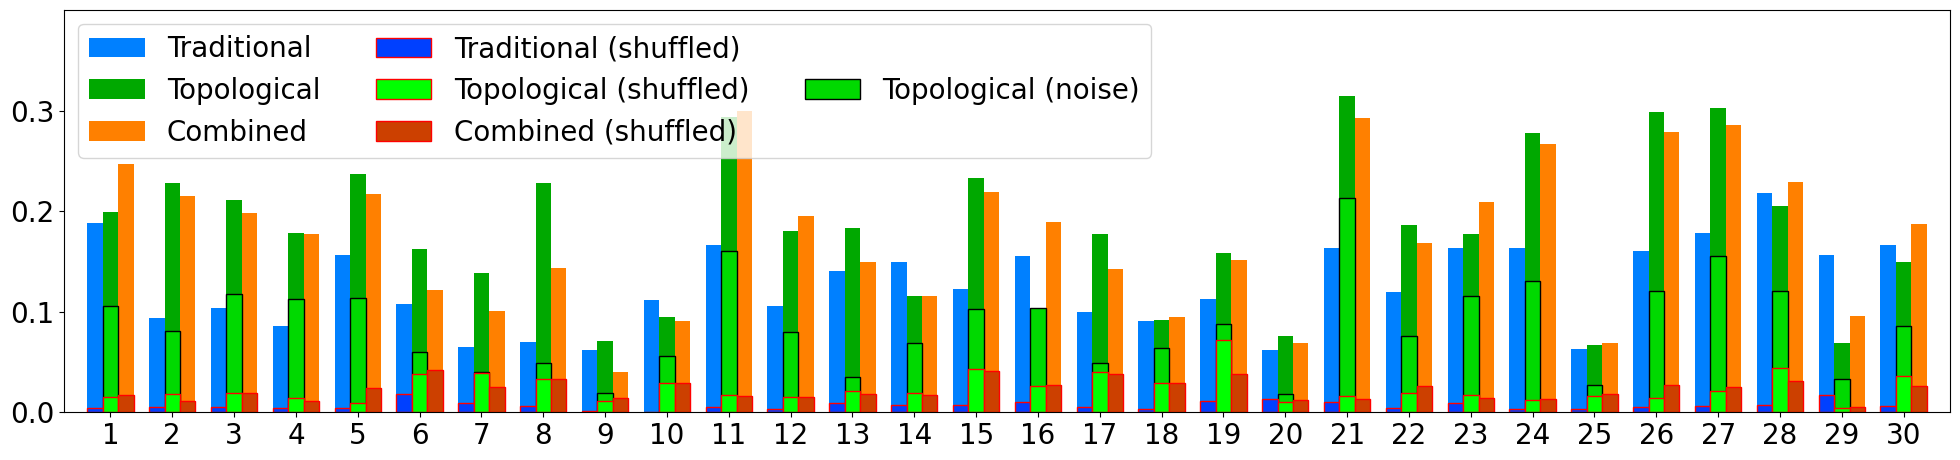

In [6]:
plt.rcParams.update({'font.size': 20})

traditional = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_reduced_flow", "traditional") for i in range(1, 31) ]
best_topological = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_reduced_flow", "best_topological") for i in range(1, 31) ]
combined = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_reduced_flow", "combined") for i in range(1, 31) ]

shuffled_traditional = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_shuffled", "traditional") for i in range(1, 31) ]
shuffled_best_topological = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_shuffled", "best_topological") for i in range(1, 31) ]
shuffled_combined = [ get_silh("E:/CourseProject", f"phase2/Subj{i}", "exp_shuffled", "combined") for i in range(1, 31) ]

noise_best_topological = [ get_silh("./", f"phase2/Subj{i}", "exp_noise", "best_topological") for i in range(1, 31) ]

fig, ax = plt.subplots(1, 1, figsize = (20, 5))
x = numpy.array(range(1, 31))
ax.set_ylim(0, 0.4)
WIDTH = 0.25

b1 = ax.bar(x, traditional, width = WIDTH, color = (0, 0.5, 1), label = 'Traditional')
b2 = ax.bar(x + WIDTH, best_topological, width = WIDTH, color = (0, 0.66, 0), label = 'Topological')
b3 = ax.bar(x + 2 * WIDTH, combined, width = WIDTH, color = (1, 0.5, 0), label = 'Combined')

b4 = ax.bar(x + WIDTH, noise_best_topological, width = WIDTH, edgecolor = 'black', color = (0, 0.85, 0), label = 'Topological (noise)')

b5 = ax.bar(x, shuffled_traditional, width = WIDTH, edgecolor = 'red', color = (0, 0.25, 1), label = 'Traditional (shuffled)')
b6 = ax.bar(x + WIDTH, shuffled_best_topological, width = WIDTH, edgecolor = 'red', color = (0, 1, 0), label = 'Topological (shuffled)')
b7 = ax.bar(x + 2 * WIDTH, shuffled_combined, width = WIDTH, edgecolor = 'red', color = (0.8, 0.25, 0), label = 'Combined (shuffled)')

import matplotlib.patches as mpatches
dummy = mpatches.Patch(facecolor='none', edgecolor='none', label="")

ax.set_xlim(0.5, 31)
ax.set_xticks(x + WIDTH, x)
ax.set_yticks([0, 0.1, 0.2, 0.3])
ax.legend(
    [b1, b2, b3, b5, b6, b7, dummy, b4, dummy],
    ['Traditional', 'Topological', 'Combined', 'Traditional (shuffled)', 'Topological (shuffled)', 'Combined (shuffled)', '', 'Topological (noise)', ''],
    ncol = 3, loc = 'upper left'
)
fig.tight_layout()
fig.savefig("phase2_scores.svg")

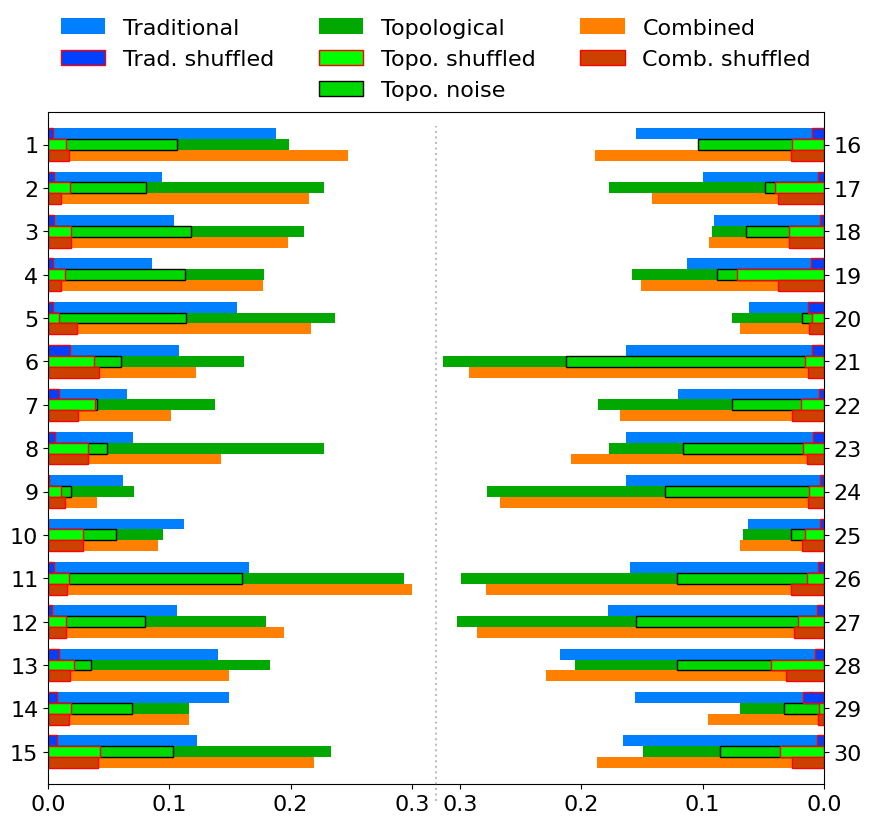

In [64]:
plt.rcParams.update({'font.size': 16})

WIDTH = 0.25

def plot_panel(ax, start, end, invert_x=False):
    n = end - start + 1
    x = numpy.arange(1, n + 1)
    sl = slice(start - 1, end)

    t   = traditional[sl];              bt  = best_topological[sl]
    c   = combined[sl];                 nbt = noise_best_topological[sl]
    st  = shuffled_traditional[sl];     sbt = shuffled_best_topological[sl]
    sc  = shuffled_combined[sl]

    ax.set_xlim(0, 0.4)

    b1 = ax.barh(x,             t,  height=WIDTH, color=(0, 0.5, 1))
    b2 = ax.barh(x + WIDTH,     bt, height=WIDTH, color=(0, 0.66, 0))
    b3 = ax.barh(x + 2 * WIDTH, c,  height=WIDTH, color=(1, 0.5, 0))

    b4 = ax.barh(x + WIDTH, nbt, height=WIDTH, edgecolor='black', color=(0, 0.85, 0))

    b5 = ax.barh(x,             st,  height=WIDTH, edgecolor='red', color=(0, 0.25, 1))
    b6 = ax.barh(x + WIDTH,     sbt, height=WIDTH, edgecolor='red', color=(0, 1, 0))
    b7 = ax.barh(x + 2 * WIDTH, sc,  height=WIDTH, edgecolor='red', color=(0.8, 0.25, 0))

    ax.set_ylim(0.5, 16)  # fixed at 15 rows/panel so both panels align exactly
    ax.set_xlim(0, 0.32)
    ax.set_yticks(x + WIDTH, range(start, end + 1))
    ax.set_xticks([0, 0.1, 0.2, 0.3])
    ax.invert_yaxis()

    if invert_x:
        ax.invert_xaxis()
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position('right')
        ax.spines['left'].set_visible(False)
    else:
        ax.spines['right'].set_visible(False)

    return b1, b2, b3, b4, b5, b6, b7

fig, axes = plt.subplots(1, 2, figsize=(9, 7.5), gridspec_kw={'wspace': 0})

plot_panel(axes[0], 1, 15, invert_x=False)
handles = plot_panel(axes[1], 16, 30, invert_x=True)

import matplotlib.patches as mpatches
dummy = mpatches.Patch(facecolor='none', edgecolor='none', label="")

fig.add_artist(plt.Line2D(
    [0.5, 0.5], [0.05, 0.95], transform=fig.transFigure, color='gray', linestyle=':', alpha=0.5
))
fig.legend(
    [handles[0],    handles[4],    dummy,  handles[1],   handles[5],       handles[3], handles[2],   handles[6], dummy],
    ['Traditional', 'Trad. shuffled', '', 'Topological', 'Topo. shuffled', 'Topo. noise', 'Combined', 'Comb. shuffled', ''],
    loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.12), frameon=False
)

fig.tight_layout()
fig.savefig("phase2_scores_hist.svg", bbox_inches='tight')

In [55]:
import tqdm

ch_names = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FT7', 'FC3',
    'FCz', 'FC4', 'FT8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP7',
    'CP3', 'CPz', 'CP4', 'TP8', 'T5', 'P3', 'P4', 'T6', 'P5',
    'PO3', 'PO4', 'P6', 'PO7', 'O1', 'O2', 'PO8'
]
ch_name_renamer = {
    'AF1': 'F3',
    'AF2': 'F4',
    'FFC5h': 'FT7',
    'FFC3h': 'FC3',
    'FFC4h': 'FC4',
    'FFC6h': 'FT8',
    'FCC5h': 'T3',
    'FCC3h': 'C3',
    'FCC4h': 'C4',
    'FCC6h': 'T4',
    'T8': 'TP8',
    'CCP5h': 'T5',
    'CCP3h': 'CP3',
    'CCP4h': 'CP4',
    'CCP6h': 'T6',
    'CPP5h': 'P5',
    'CPP3h': 'P3',
    'CPP4h': 'P4',
    'CPP6h': 'P6',
    'P7': 'PO7',
    'P8': 'PO8',
    'T7': 'TP7'
}

def get_iv_qsda(subj):
    iv = pandas.read_csv(f"E:/CourseProject/{subj}/exp_reduced_flow/IV/IV.csv")
    qsda = pandas.read_csv(f"E:/CourseProject/{subj}/exp_reduced_flow/qsda/scores.csv")
    iv_qsda = qsda.join(iv, lsuffix = "name", rsuffix = "Feature")
    iv_qsda["score"] = iv_qsda["score"] * (iv_qsda["unique_values"] >= 200)
    iv_qsda[["Source", "Algorithm", "Dimension", "Stat"]] = iv_qsda['name'].str.split(' ', expand = True)
    iv_qsda["Source"] = iv_qsda.apply(SourceFilter, axis = 1)

    iv_qsda['channel_id'] = iv_qsda['Source'].apply(
        lambda source: source[len('channel-'):] if source.startswith('channel-') else None
    )
    iv_qsda = iv_qsda[~iv_qsda["channel_id"].isna()][["channel_id", "score", "IV"]]

    epochs = mne.read_epochs(f"E:/CourseProject/{subj}/src/epochs_filt_rr-epo.fif", verbose='error')
    def calc_channel_name(channel_id):
        channel_name = epochs.ch_names[int(channel_id)]
        if channel_name in ch_name_renamer:
            channel_name = ch_name_renamer[channel_name]
        if channel_name not in ch_names:
            return None
        return channel_name
        
    iv_qsda['channel_name'] = iv_qsda['channel_id'].apply(calc_channel_name)
    iv_qsda = iv_qsda[~iv_qsda["channel_name"].isna()]
    return iv_qsda[["channel_name", "score", "IV"]]

iv_qsda = pandas.concat([ get_iv_qsda(f"phase2/Subj{i}") for i in tqdm.trange(1, 31) ])

iv_scores, qsda_scores = {}, {}
for _, row in iv_qsda.groupby(by = 'channel_name').mean().reset_index().iterrows():
    iv_scores[row["channel_name"]] = row["IV"]
    qsda_scores[row["channel_name"]] = row["score"]


open("sda_main_heatmap_iv.svg", "w").write(SDA.analytics.draw_sources_heatmap(iv_scores))
open("sda_main_heatmap_qsda.svg", "w").write(SDA.analytics.draw_sources_heatmap(qsda_scores))

100%|██████████| 30/30 [00:09<00:00,  3.13it/s]


145717